In [4]:
!pip install -q scikit-learn plotly ipywidgets
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import plotly.express as px


In [5]:
digits = load_digits()

X = digits.data        # shape: (1797, 64)
y = digits.target      # true labels (0–9)

print("Data shape:", X.shape)
print("Labels shape:", y.shape)


Data shape: (1797, 64)
Labels shape: (1797,)


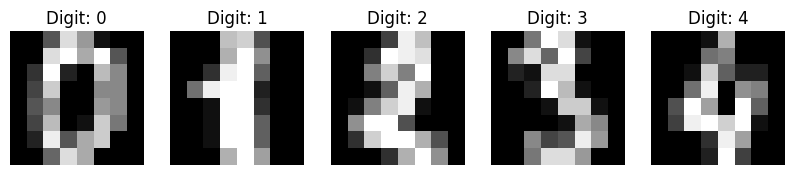

In [6]:
fig, axes = plt.subplots(1, 5, figsize=(10,3))
for ax, img, label in zip(axes, digits.images[:5], y[:5]):
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Digit: {label}")
    ax.axis('off')
plt.show()


In [7]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init='pca',
    learning_rate='auto'
)

X_tsne = tsne.fit_transform(X)

print("t-SNE output shape:", X_tsne.shape)


t-SNE output shape: (1797, 2)


In [23]:
k = int(input()) # number of clusters

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_tsne)

print("Unique clusters:", np.unique(clusters))


16
Unique clusters: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]


In [24]:
sil_score = silhouette_score(X_tsne, clusters)

print("Silhouette Score:", round(sil_score, 3))


Silhouette Score: 0.563


In [25]:
fig = px.scatter(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    color=clusters,
    title="MNIST Digit Clustering using t-SNE + K-Means",
    labels={'color': 'Cluster'},
    hover_data={
        "True Digit": y,
        "Cluster": clusters
    },
    category_orders={"color": list(range(10))}
)

fig.update_traces(marker=dict(size=6))
fig.show()



In [11]:
import pandas as pd

df = pd.DataFrame({
    "Digit": y,
    "Cluster": clusters
})

cluster_stats = df.groupby("Cluster")["Digit"].agg(
    Count="count",
    Most_Common=lambda x: x.value_counts().idxmax()
)

print(cluster_stats)


         Count  Most_Common
Cluster                    
0          181            3
1          170            1
2          178            0
3          181            6
4          184            5
5          193            7
6          194            2
7          178            4
8          194            8
9          144            9
